# Shapley Methods — Cross-Dataset Summary

Aggregated metrics across all 4 synthetic datasets. Reuses helper functions from `analysis_utils.py`.

| Dataset | Confounders | Data type |
|---------|------------|-----------|
| `linear_conf_f50_s1000_p50` | Yes | Linear |
| `linear_no_conf_f50_s1000_p50` | No | Linear |
| `mixed_conf_f50_s1000_p50` | Yes | Mixed |
| `mixed_no_conf_f50_s1000_p50` | No | Mixed |

**Metrics computed:**
- **Spearman ρ** vs Scratch — feature ranking correlation
- **Top-K Jaccard** vs Scratch — feature set overlap at K = 5, 10, 20
- **True-parent Precision@K** — fraction of top-K that are true Y-parents
- **GSS** — Graph Sensitivity Score (PC vs LiNGAM magnitude shift)
- **Sign Alignment** vs True graph — fraction of instances with matching sign
- **Magnitude TGA** vs True graph — relative magnitude deviation

In [1]:
import sys
import importlib
from pathlib import Path as _Path
sys.path.insert(0, str(_Path("..").resolve()))

import numpy as np
import pandas as pd
import plotly.graph_objects as go
import plotly.express as px
from plotly.subplots import make_subplots
import json
from pathlib import Path
import warnings
warnings.filterwarnings("ignore")

from scipy.stats import spearmanr

# Force reload so any changes to analysis_utils.py are picked up
if "analysis_utils" in sys.modules:
    importlib.reload(sys.modules["analysis_utils"])

from analysis_utils import (
    mean_abs_shap, top_k_jaccard,
    compute_sign_alignment, compute_tga, compute_sss,
    compute_gss, top_k_features, rank_shift_top_k,
    flow_graph_stats,
    build_dag_graph, make_dag_pos, draw_dag_highlight,
)

# ── Paths ─────────────────────────────────────────────────────────────────────
BASE_DIR           = Path("..").resolve()
EXPLAINABILITY_DIR = BASE_DIR / "data" / "explainability"
CAUSAL_DIR         = BASE_DIR / "data" / "causal"
PROCESSED_DIR      = BASE_DIR / "data" / "processed"
SYNTHETIC_DIR      = BASE_DIR / "data" / "synthetic"

# ── Datasets to compare ───────────────────────────────────────────────────────
DATASETS = [
    "linear_conf_f50_s1000_p50",
    # "linear_no_conf_f50_s1000_p50",
    # "mixed_conf_f50_s1000_p50",
    # "mixed_no_conf_f50_s1000_p50",
]
MODEL = "lgbm"
K_VALUES     = [5, 10, 20]
BASE_METHODS = ["Asymmetric", "Causal", "Flow"]
DISC_GRAPHS  = ["PC", "LiNGAM"]

METHOD_COLORS = {
    "Scratch":    "#636363",
    "Asymmetric": "#2166ac",
    "Causal":     "#4dac26",
    "Flow":       "#d01c8b",
}
# Short dataset labels for display
DS_LABELS = {
    "linear_conf_f50_s1000_p50":     "Lin-Conf",
    "linear_no_conf_f50_s1000_p50":  "Lin-NoConf",
    "mixed_conf_f50_s1000_p50":      "Mix-Conf",
    "mixed_no_conf_f50_s1000_p50":   "Mix-NoConf",
}

print("Setup complete. Datasets:", DATASETS)


Setup complete. Datasets: ['linear_conf_f50_s1000_p50']


## 1. Load All Data

Load Shapley values, causal graphs, metadata, and pre-computed true-graph arrays for every dataset.

In [2]:
def load_dataset(dataset: str, model: str = "lgbm") -> dict:
    """
    Load all Shapley values, causal graphs, metadata, and true-graph arrays
    for one dataset. Returns a dict with all data needed for metric computation.
    """
    exp_base = EXPLAINABILITY_DIR / dataset / model
    causal   = CAUSAL_DIR

    # ── Main SHAP data (from pipeline output) ─────────────────────────────
    keys = {
        "Scratch":             exp_base / "scratch"  / "shapley_values.npy",
        "Asymmetric (PC)":     exp_base / "pc"        / "asymmetric" / "shapley_values.npy",
        "Causal (PC)":         exp_base / "pc"        / "causal"     / "shapley_values.npy",
        "Flow (PC)":           exp_base / "pc"        / "flow"       / "shapley_values.npy",
        "Asymmetric (LiNGAM)": exp_base / "lingam"   / "asymmetric" / "shapley_values.npy",
        "Causal (LiNGAM)":     exp_base / "lingam"   / "causal"     / "shapley_values.npy",
        "Flow (LiNGAM)":       exp_base / "lingam"   / "flow"       / "shapley_values.npy",
    }
    subset_keys = {
        "Asymmetric (PC)":     exp_base / "pc"        / "asymmetric" / "shapley_values.npy",
        "Causal (PC)":         exp_base / "pc"        / "causal"     / "shapley_values.npy",
        "Flow (PC)":           exp_base / "pc"        / "flow"       / "shapley_values.npy",
        "Asymmetric (LiNGAM)": exp_base / "lingam"   / "asymmetric" / "shapley_values.npy",
        "Causal (LiNGAM)":     exp_base / "lingam"   / "causal"     / "shapley_values.npy",
        "Flow (LiNGAM)":       exp_base / "lingam"   / "flow"       / "shapley_values.npy",
        "Asymmetric (True)":   exp_base / "true"      / "asymmetric" / "shapley_values.npy",
        "Causal (True)":       exp_base / "true"      / "causal"     / "shapley_values.npy",
        "Flow (True)":         exp_base / "true"      / "flow"       / "shapley_values.npy",
    }

    shap_data        = {k: np.load(v) for k, v in keys.items()        if v.exists()}
    subset_shap_data = {k: np.load(v) for k, v in subset_keys.items() if v.exists()}

    # ── Feature names ──────────────────────────────────────────────────────
    with open(causal / f"{dataset}_pc_results.json") as f:
        pc_results = json.load(f)
    with open(causal / f"{dataset}_lingam_results.json") as f:
        lingam_results = json.load(f)
    feature_names = [n for n in pc_results["feature_names"] if n != "Y"]

    # ── True Y-parents ─────────────────────────────────────────────────────
    with open(SYNTHETIC_DIR / f"{dataset}_metadata.json") as f:
        meta = json.load(f)
    y_parent_set = set(meta["y_parent_indices"])

    # ── Graph stats ────────────────────────────────────────────────────────
    pc_edges,     pc_sources     = flow_graph_stats(pc_results["adjacency_matrix"],     len(feature_names))
    lingam_edges, lingam_sources = flow_graph_stats(lingam_results["adjacency_matrix"], len(feature_names))

    return dict(
        shap_data        = shap_data,
        subset_shap_data = subset_shap_data,
        feature_names    = feature_names,
        y_parent_set     = y_parent_set,
        pc_edges         = pc_edges,
        lingam_edges     = lingam_edges,
    )


# Load all datasets
all_data = {}
for ds in DATASETS:
    all_data[ds] = load_dataset(ds)
    n_shap = all_data[ds]["shap_data"]["Scratch"].shape[0]
    n_feat = len(all_data[ds]["feature_names"])
    n_par  = len(all_data[ds]["y_parent_set"])
    loaded = len(all_data[ds]["shap_data"])
    sub_loaded = len(all_data[ds]["subset_shap_data"])
    print(f"  {DS_LABELS[ds]:12s}  {loaded} main SHAP + {sub_loaded} subset  "
          f"n_shap={n_shap}  n_feat={n_feat}  true_parents={n_par}")

  Lin-Conf      7 main SHAP + 9 subset  n_shap=100  n_feat=50  true_parents=25


## 2. Compute All Metrics

For each dataset × method × graph, compute Spearman ρ, Top-K Jaccard, Precision@K, and GSS.

In [3]:
all_metrics = []   # list of dicts, one per (dataset, method, graph)
gss_metrics = []   # one per (dataset, method)
tga_metrics = []   # one per (dataset, method, graph)
sa_metrics  = []   # sign alignment, one per (dataset, method, graph)

for ds in DATASETS:
    d             = all_data[ds]
    shap_data     = d["shap_data"]
    subset_shap   = d["subset_shap_data"]
    feature_names = d["feature_names"]
    y_parent_set  = d["y_parent_set"]
    n_feat        = len(feature_names)
    random_base   = len(y_parent_set) / n_feat

    scratch_ma = mean_abs_shap(shap_data, "Scratch")

    # ── Spearman ρ, Jaccard, Precision@K ──────────────────────────────────
    for meth in BASE_METHODS:
        for g in DISC_GRAPHS:
            key = f"{meth} ({g})"
            if key not in shap_data:
                continue
            ma = mean_abs_shap(shap_data, key)
            rho, _ = spearmanr(ma, scratch_ma)
            for k in K_VALUES:
                jacc = top_k_jaccard(ma, scratch_ma, k)
                top_k_idx = set(np.argsort(ma)[-k:])
                prec = len(top_k_idx & y_parent_set) / k
                all_metrics.append(dict(
                    Dataset     = DS_LABELS[ds],
                    DatasetFull = ds,
                    Method      = meth,
                    Graph       = g,
                    K           = k,
                    Spearman    = float(rho),
                    Jaccard     = float(jacc),
                    Precision   = float(prec),
                    RandomBase  = float(random_base),
                ))

    # ── Scratch Precision@K (reference) ───────────────────────────────────
    scratch_ma_arr = mean_abs_shap(shap_data, "Scratch")
    for k in K_VALUES:
        top_k_idx = set(np.argsort(scratch_ma_arr)[-k:])
        prec = len(top_k_idx & y_parent_set) / k
        all_metrics.append(dict(
            Dataset="Scratch", DatasetFull=ds, Method="Scratch", Graph="—",
            K=k, Spearman=np.nan, Jaccard=np.nan, Precision=float(prec),
            RandomBase=float(random_base),
        ))

    # ── GSS — signed magnitude difference (no outer abs, no normalisation) ─
    # GSS_f(m) = mean_i ( |φ^PC_{i,f}| - |φ^LiNGAM_{i,f}| )
    # Positive = PC assigns higher mean importance; negative = LiNGAM higher.
    for meth in BASE_METHODS:
        pc_k  = f"{meth} (PC)"
        lg_k  = f"{meth} (LiNGAM)"
        if pc_k not in shap_data or lg_k not in shap_data:
            continue
        raw = (np.abs(shap_data[pc_k]) - np.abs(shap_data[lg_k])).mean(axis=0)
        gss_metrics.append(dict(
            Dataset   = DS_LABELS[ds],
            Method    = meth,
            MeanGSS   = float(np.mean(raw)),
            MedianGSS = float(np.median(raw)),
        ))

    # ── Sign Alignment vs True ─────────────────────────────────────────────
    sign_align = compute_sign_alignment(subset_shap, BASE_METHODS, DISC_GRAPHS)
    for (meth, g), arr in sign_align.items():
        sa_metrics.append(dict(
            Dataset    = DS_LABELS[ds],
            Method     = meth,
            Graph      = g,
            MeanSignAlign = float(np.nanmean(arr)),
        ))

    # ── Magnitude TGA vs True ──────────────────────────────────────────────
    tga_data, _ = compute_tga(subset_shap, feature_names, BASE_METHODS, DISC_GRAPHS)
    for (meth, g), arr in tga_data.items():
        tga_metrics.append(dict(
            Dataset = DS_LABELS[ds],
            Method  = meth,
            Graph   = g,
            MeanTGA = float(np.mean(arr)),
        ))

df_metrics = pd.DataFrame(all_metrics)
df_gss     = pd.DataFrame(gss_metrics)
df_sa      = pd.DataFrame(sa_metrics)
df_tga     = pd.DataFrame(tga_metrics)

print(f"Metrics rows: all={len(df_metrics)}  gss={len(df_gss)}  sa={len(df_sa)}  tga={len(df_tga)}")


Metrics rows: all=21  gss=3  sa=6  tga=6


## 3. Cross-Dataset Comparison

### 3a — Spearman ρ vs Scratch  
Feature ranking correlation between each causal method and the graph-free Scratch baseline.

### 3b — Top-K Jaccard vs Scratch  
Fraction of the top-K features shared with Scratch's top-K set.

### 3c — True-Parent Precision@K  
Fraction of the top-K features that are true causal parents of Y.

In [4]:
# ── 3a: Spearman ρ heatmap — method×graph rows, dataset columns ──────────────
df_rho = df_metrics[df_metrics["Method"].isin(BASE_METHODS)].drop_duplicates(
    subset=["Dataset", "DatasetFull", "Method", "Graph", "Spearman"]
)[["DatasetFull", "Method", "Graph", "Spearman"]].dropna()
# Take one row per (dataset, method, graph) — Spearman doesn't depend on K
df_rho = df_rho.groupby(["DatasetFull", "Method", "Graph"], as_index=False)["Spearman"].first()

pivot_rho = df_rho.pivot_table(
    index=["Method", "Graph"], columns="DatasetFull", values="Spearman"
)
pivot_rho = pivot_rho[[ds for ds in DATASETS if ds in pivot_rho.columns]]

row_labels = [f"{m} ({g})" for m, g in pivot_rho.index]
col_labels = [DS_LABELS[c] for c in pivot_rho.columns]

fig_rho = go.Figure(go.Heatmap(
    z            = pivot_rho.values,
    x            = col_labels,
    y            = row_labels,
    colorscale   = "RdYlGn",
    zmin=0.5, zmax=1.0,
    text         = [[f"{v:.3f}" for v in row] for row in pivot_rho.values],
    texttemplate = "%{text}",
    textfont     = dict(size=12),
    colorbar     = dict(title=dict(text="Spearman ρ", font=dict(size=11))),
    hovertemplate="<b>%{y}</b> — %{x}<br>ρ = %{z:.3f}<extra></extra>",
))
fig_rho.update_layout(
    title=dict(text="Spearman ρ vs Scratch — All Datasets<br>"
               "<sup>1.0 = same feature ranking as graph-free baseline</sup>",
               font=dict(size=13)),
    height=320, width=700,
    margin=dict(l=160, r=80, t=80, b=60),
    xaxis=dict(tickfont=dict(size=11), tickangle=-20),
    yaxis=dict(tickfont=dict(size=10)),
)
fig_rho.show()

In [5]:
# ── 3b: Top-K Jaccard grouped bar — one subplot per dataset ──────────────────
fig_jacc = make_subplots(
    rows=1, cols=4,
    subplot_titles=[DS_LABELS[ds] for ds in DATASETS],
    shared_yaxes=True,
)
GRAPH_DASH = {"PC": "solid", "LiNGAM": "dash"}
GRAPH_SYMBOL = {"PC": "circle", "LiNGAM": "diamond"}
LEGEND_SEEN = set()

for col_i, ds in enumerate(DATASETS, start=1):
    sub = df_metrics[(df_metrics["DatasetFull"] == ds) & (df_metrics["Method"].isin(BASE_METHODS))]
    for meth in BASE_METHODS:
        for g in DISC_GRAPHS:
            rows = sub[(sub["Method"] == meth) & (sub["Graph"] == g)].sort_values("K")
            if rows.empty:
                continue
            name   = f"{meth} ({g})"
            show   = name not in LEGEND_SEEN
            LEGEND_SEEN.add(name)
            fig_jacc.add_trace(
                go.Scatter(
                    x         = rows["K"].tolist(),
                    y         = rows["Jaccard"].tolist(),
                    mode      = "lines+markers",
                    name      = name,
                    legendgroup = name,
                    showlegend  = show,
                    line      = dict(color=METHOD_COLORS[meth], dash=GRAPH_DASH[g]),
                    marker    = dict(symbol=GRAPH_SYMBOL[g], size=7),
                    hovertemplate=f"<b>{name}</b><br>K=%{{x}}<br>Jaccard=%{{y:.3f}}<extra></extra>",
                ),
                row=1, col=col_i,
            )

fig_jacc.update_layout(
    title=dict(text="Top-K Jaccard vs Scratch<br><sup>Lines = method, style = graph (solid=PC, dashed=LiNGAM)</sup>",
               font=dict(size=13)),
    height=350, width=900,
    legend=dict(x=1.01, y=1, xanchor="left", font=dict(size=10)),
    margin=dict(l=60, r=200, t=80, b=60),
)
fig_jacc.update_xaxes(tickvals=K_VALUES, title_text="K")
fig_jacc.update_yaxes(range=[0, 1.05], title_text="Jaccard", col=1)
fig_jacc.show()

In [6]:
# ── 3c: True-parent Precision@K — one subplot per K-value ───────────────────
fig_prec = make_subplots(
    rows=1, cols=len(K_VALUES),
    subplot_titles=[f"Precision@{k}" for k in K_VALUES],
    shared_yaxes=True,
)
LEGEND_SEEN2 = set()
combos = [(m, g) for m in BASE_METHODS for g in DISC_GRAPHS]

for ci, k in enumerate(K_VALUES, start=1):
    sub = df_metrics[(df_metrics["K"] == k) & (df_metrics["Method"].isin(BASE_METHODS))]
    for meth, g in combos:
        rows = sub[(sub["Method"] == meth) & (sub["Graph"] == g)]
        if rows.empty:
            continue
        name = f"{meth} ({g})"
        show = name not in LEGEND_SEEN2
        LEGEND_SEEN2.add(name)
        fig_prec.add_trace(
            go.Bar(
                x           = [DS_LABELS[rows.iloc[i]["DatasetFull"]] for i in range(len(rows))],
                y           = rows["Precision"].tolist(),
                name        = name,
                legendgroup = name,
                showlegend  = show,
                marker_color= METHOD_COLORS[meth],
                opacity     = 0.7 if g == "LiNGAM" else 1.0,
                hovertemplate=f"<b>{name}</b><br>Prec=%{{y:.3f}}<extra></extra>",
            ),
            row=1, col=ci,
        )
    # Random baseline line
    random_vals = df_metrics[(df_metrics["K"] == k) & (df_metrics["Method"].isin(BASE_METHODS))]
    if not random_vals.empty:
        xs = [DS_LABELS[ds] for ds in DATASETS]
        fig_prec.add_trace(
            go.Scatter(
                x=xs, y=[random_vals.groupby("DatasetFull")["RandomBase"].first().get(ds, 0) for ds in DATASETS],
                mode="lines", line=dict(dash="dash", color="black", width=1.2),
                name="Random", legendgroup="Random", showlegend=(ci == 1),
                hovertemplate="Random baseline<br>Prec=%{y:.3f}<extra></extra>",
            ),
            row=1, col=ci,
        )

fig_prec.update_layout(
    title=dict(text="True-Parent Precision@K<br><sup>Dashed black line = random baseline (n_parents/n_features)</sup>",
               font=dict(size=13)),
    height=360, width=900,
    barmode="group",
    legend=dict(x=1.01, y=1, xanchor="left", font=dict(size=10)),
    margin=dict(l=60, r=200, t=80, b=80),
)
fig_prec.update_yaxes(range=[0, 1.05], title_text="Precision", col=1)
fig_prec.update_xaxes(tickangle=-25)
fig_prec.show()

## 4. Graph Sensitivity Score (GSS)

How much does each method's output shift between the PC and LiNGAM graphs?  
Lower is more stable under graph uncertainty. GSS = 1 means the largest shift across all methods.

In [7]:
# GSS grouped bar — dataset × method
fig_gss = go.Figure()
for meth in BASE_METHODS:
    sub = df_gss[df_gss["Method"] == meth]
    fig_gss.add_trace(go.Bar(
        name         = meth,
        x            = sub["Dataset"].tolist(),
        y            = sub["MeanGSS"].tolist(),
        marker_color = METHOD_COLORS[meth],
        error_y      = None,
        hovertemplate=f"<b>{meth}</b><br>Dataset=%{{x}}<br>MeanGSS=%{{y:.4f}}<extra></extra>",
    ))

fig_gss.update_layout(
    title=dict(text="Graph Sensitivity Score (Mean GSS) — Near 0 = PC and LiNGAM Agree<br>"
               "<sup>Signed magnitude difference: positive = PC higher, negative = LiNGAM higher</sup>",
               font=dict(size=13)),
    barmode="group",
    yaxis=dict(title="Mean GSS", zeroline=True, zerolinewidth=1.5, zerolinecolor="gray"),
    height=380, width=700,
    legend=dict(x=0.01, y=0.99, xanchor="left", font=dict(size=11)),
    margin=dict(l=70, r=30, t=90, b=80),
    xaxis=dict(tickangle=-20),
)
fig_gss.show()


## 4b. Sign Stability Score (SSS) & Cross-Evaluation with GSS

**SSS** is the sign-domain analogue of the True-Graph Alignment sign metric: for each (instance, feature) pair we ask whether the *sign* of the SHAP value **agrees** between the PC and LiNGAM graph — consistent with how `compute_sign_alignment` compares a discovered graph against the True DAG.

$$\text{SSS}(m, f) = \frac{1}{|\{i : \phi^{PC}_{i,f} \neq 0 \;\wedge\; \phi^{LiNGAM}_{i,f} \neq 0\}|} \sum_i \mathbf{1}\!\left[\text{sign}\!\left(\phi^{PC}_{i,f}\right) = \text{sign}\!\left(\phi^{LiNGAM}_{i,f}\right)\right]$$

Higher SSS = signs are **more consistent** between the two discovered graphs (more stable).

The **cross-evaluation scatter** places every (method × dataset) in a common stability space where both axes measure instability (lower = more stable):
- **x-axis — GSS**: magnitude instability between PC and LiNGAM  
- **y-axis — (1 − SSS)**: sign flip rate between PC and LiNGAM  
- **Bottom-left corner** = maximally stable across both dimensions.

In [8]:
# ── Compute SSS via analysis_utils.compute_sss ────────────────────────────────
# Returns dict: method → ndarray(n_features,) agreement rate in [0, 1].
# Higher = signs more consistent between PC and LiNGAM graphs.

sss_metrics = []

for ds in DATASETS:
    d         = all_data[ds]
    shap_data = d["shap_data"]

    sss_per_method = compute_sss(shap_data, BASE_METHODS)

    for meth, feat_arr in sss_per_method.items():
        sss_metrics.append(dict(
            Dataset = DS_LABELS[ds],
            Method  = meth,
            MeanSSS = float(np.nanmean(feat_arr)),
        ))

df_sss = pd.DataFrame(sss_metrics)
print(df_sss.to_string(index=False))

 Dataset     Method  MeanSSS
Lin-Conf Asymmetric 0.888200
Lin-Conf     Causal 0.659600
Lin-Conf       Flow 0.679062


In [9]:
# ── SSS bar chart ─────────────────────────────────────────────────────────────
fig_sss = go.Figure()
for meth in BASE_METHODS:
    sub = df_sss[df_sss["Method"] == meth]
    fig_sss.add_trace(go.Bar(
        name         = meth,
        x            = sub["Dataset"].tolist(),
        y            = sub["MeanSSS"].tolist(),
        marker_color = METHOD_COLORS[meth],
        hovertemplate=f"<b>{meth}</b><br>Dataset=%{{x}}<br>MeanSSS=%{{y:.3f}}<extra></extra>",
    ))

fig_sss.update_layout(
    title=dict(text="Sign Stability Score (Mean SSS) — Higher = More Stable<br>"
               "<sup>Fraction of (instance, feature) pairs where SHAP sign agrees between PC and LiNGAM</sup>",
               font=dict(size=13)),
    barmode="group",
    yaxis=dict(title="Mean SSS (sign agreement)", range=[0, 1.05]),
    height=380, width=700,
    legend=dict(x=0.01, y=0.01, xanchor="left", font=dict(size=11)),
    margin=dict(l=70, r=30, t=90, b=80),
    xaxis=dict(tickangle=-20),
)
fig_sss.show()

In [10]:
# ── Cross-evaluation: GSS vs (1 − SSS) scatter ────────────────────────────────
# x: GSS (signed)   — positive = PC assigns higher importance on average
#                     negative = LiNGAM assigns higher importance on average
# y: 1 − MeanSSS    — sign flip rate between PC and LiNGAM
df_cross = df_gss[["Dataset", "Method", "MeanGSS"]].merge(
    df_sss[["Dataset", "Method", "MeanSSS"]],
    on=["Dataset", "Method"],
)
df_cross["SignFlipRate"] = 1 - df_cross["MeanSSS"]

DATASET_MARKERS = {
    "Lin-Conf":   "circle",
    "Lin-NoConf": "diamond",
    "Mix-Conf":   "square",
    "Mix-NoConf": "cross",
}

fig_cross = go.Figure()
SEEN_METHODS  = set()
SEEN_DATASETS = set()

for _, row in df_cross.iterrows():
    meth = row["Method"]
    ds   = row["Dataset"]
    show_meth = meth not in SEEN_METHODS
    SEEN_METHODS.add(meth)

    fig_cross.add_trace(go.Scatter(
        x    = [row["MeanGSS"]],
        y    = [row["SignFlipRate"]],
        mode = "markers",
        name = meth,
        legendgroup = meth,
        showlegend  = show_meth,
        marker = dict(
            color  = METHOD_COLORS[meth],
            symbol = DATASET_MARKERS.get(ds, "circle"),
            size   = 13,
            line   = dict(width=1.2, color="white"),
        ),
        hovertemplate=(
            f"<b>{meth}</b><br>"
            f"Dataset: {ds}<br>"
            "GSS (signed magnitude bias): %{x:.4f}<br>"
            "Sign flip rate (1−SSS): %{y:.3f}<extra></extra>"
        ),
    ))

# Dataset shape legend (invisible traces)
for ds_label, symbol in DATASET_MARKERS.items():
    fig_cross.add_trace(go.Scatter(
        x=[None], y=[None], mode="markers",
        name=ds_label,
        legendgroup=f"ds_{ds_label}",
        showlegend=True,
        marker=dict(color="gray", symbol=symbol, size=11),
    ))

# Symmetric x-axis range around 0 (GSS is signed)
gss_abs_max = df_cross["MeanGSS"].abs().max() * 1.3
y_max       = df_cross["SignFlipRate"].max() * 1.2

# Vertical reference line at x=0 (zero bias between PC and LiNGAM)
fig_cross.add_vline(
    x=0, line=dict(dash="dot", color="lightgray", width=1.5)
)
fig_cross.add_annotation(
    x=0, y=y_max * 0.97, text="PC = LiNGAM", showarrow=False,
    font=dict(size=9, color="#aaaaaa"), xanchor="center",
)

# Quadrant labels
for qx, qy, label in [
    (-gss_abs_max * 0.6, y_max * 0.75, "LiNGAM > PC<br>Sign-unstable"),
    ( gss_abs_max * 0.6, y_max * 0.75, "PC > LiNGAM<br>Sign-unstable"),
    (-gss_abs_max * 0.6, y_max * 0.15, "LiNGAM > PC<br>Sign-stable"),
    ( gss_abs_max * 0.6, y_max * 0.15, "PC > LiNGAM<br>Sign-stable"),
]:
    fig_cross.add_annotation(
        x=qx, y=qy, text=label, showarrow=False,
        font=dict(size=9, color="#bbbbbb"), align="center",
    )

fig_cross.update_layout(
    title=dict(
        text="GSS (Signed) vs Sign Flip Rate (1 − SSS) — Magnitude Bias vs Sign Instability (PC ↔ LiNGAM)<br>"
             "<sup>x>0: PC assigns higher importance on avg; x<0: LiNGAM higher | Shape = dataset, Colour = method</sup>",
        font=dict(size=12),
    ),
    xaxis=dict(
        title="GSS — Signed Magnitude Bias",
        range=[-gss_abs_max, gss_abs_max],
        zeroline=True, zerolinewidth=1.5, zerolinecolor="gray",
    ),
    yaxis=dict(
        title="1 − SSS — Sign Flip Rate",
        range=[0, y_max],
        zeroline=False,
    ),
    height=480, width=660,
    legend=dict(x=1.02, y=1, xanchor="left", font=dict(size=11)),
    margin=dict(l=70, r=200, t=90, b=70),
)
fig_cross.show()


## 5. True-Graph Alignment

### 5a — Sign Alignment vs True DAG  
Mean fraction of instances where the causal method's SHAP sign matches the True-graph output per feature.  
Higher = more aligned with the oracle graph.

### 5b — Magnitude TGA vs True DAG  
Mean relative magnitude deviation vs True-graph output per feature.  
Lower = closer to oracle magnitude.

In [11]:
# ── 5a: Sign Alignment — faceted heatmap dataset × method per graph ──────────
for g in DISC_GRAPHS:
    sub = df_sa[df_sa["Graph"] == g]
    pivot = sub.pivot_table(index="Method", columns="Dataset", values="MeanSignAlign")
    pivot = pivot[[DS_LABELS[ds] for ds in DATASETS if DS_LABELS[ds] in pivot.columns]]

    row_labels = pivot.index.tolist()
    col_labels = pivot.columns.tolist()

    fig_sa = go.Figure(go.Heatmap(
        z            = pivot.values,
        x            = col_labels,
        y            = row_labels,
        colorscale   = "Blues",
        zmin=0.5, zmax=1.0,
        text         = [[f"{v:.3f}" if not np.isnan(v) else "—" for v in row] for row in pivot.values],
        texttemplate = "%{text}",
        textfont     = dict(size=12),
        colorbar     = dict(title=dict(text="Sign Align", font=dict(size=11))),
        hovertemplate=f"<b>%{{y}}</b> ({g}) — %{{x}}<br>Sign Align=%{{z:.3f}}<extra></extra>",
    ))
    fig_sa.update_layout(
        title=dict(text=f"Sign Alignment vs True DAG — {g} graph<br>"
                   "<sup>Fraction of instances where sign matches oracle</sup>",
                   font=dict(size=12)),
        height=260, width=700,
        margin=dict(l=130, r=80, t=70, b=60),
        xaxis=dict(tickfont=dict(size=11), tickangle=-15),
        yaxis=dict(tickfont=dict(size=11)),
    )
    fig_sa.show()

In [12]:
# ── 5b: Magnitude TGA heatmap per graph ───────────────────────────────────────
for g in DISC_GRAPHS:
    sub = df_tga[df_tga["Graph"] == g]
    pivot = sub.pivot_table(index="Method", columns="Dataset", values="MeanTGA")
    pivot = pivot[[DS_LABELS[ds] for ds in DATASETS if DS_LABELS[ds] in pivot.columns]]

    abs_max_tga = float(np.nanmax(np.abs(pivot.values)))

    fig_tga = go.Figure(go.Heatmap(
        z            = pivot.values,
        x            = pivot.columns.tolist(),
        y            = pivot.index.tolist(),
        colorscale   = "RdBu",
        zmid=0,
        zmin=-abs_max_tga, zmax=abs_max_tga,
        text         = [[f"{v:.4f}" if not np.isnan(v) else "—" for v in row] for row in pivot.values],
        texttemplate = "%{text}",
        textfont     = dict(size=12),
        colorbar     = dict(title=dict(text="Mean TGA", font=dict(size=11))),
        hovertemplate=f"<b>%{{y}}</b> ({g}) — %{{x}}<br>TGA=%{{z:.4f}}<extra></extra>",
    ))
    fig_tga.update_layout(
        title=dict(text=f"Magnitude TGA vs True DAG — {g} graph<br>"
                   "<sup>Signed: positive = disc overestimates True; negative = underestimates; white ≈ 0 = matches</sup>",
                   font=dict(size=12)),
        height=260, width=700,
        margin=dict(l=130, r=80, t=70, b=60),
        xaxis=dict(tickfont=dict(size=11), tickangle=-15),
        yaxis=dict(tickfont=dict(size=11)),
    )
    fig_tga.show()


## 6. Methods vs Scratch Baseline

Compares each (method × graph) against **Scratch** (graph-free SHAP) using the same sign-alignment and magnitude TGA metrics as Section 5.  
This measures how much the causal graph structure *changes* the attributions relative to the Scratch baseline, across all three graph variants (PC, LiNGAM, True).

- **Sign Alignment vs Scratch** — fraction of (instance, feature) pairs where `sign(φ_method)` matches `sign(φ_Scratch)`. Higher = output signs closer to graph-free baseline.  
- **Magnitude TGA vs Scratch** — relative magnitude deviation from Scratch. Lower = magnitudes closer to graph-free baseline.

In [13]:
# ── Compute sign alignment and TGA vs Scratch ─────────────────────────────────
# Compare every (method, graph) — including True — against Scratch.
# Uses the generalized reference="Scratch" parameter (method-independent fallback).

ALL_GRAPHS = ["PC", "LiNGAM"]   # all graph variants to evaluate vs Scratch

sa_scratch_metrics  = []
tga_scratch_metrics = []

for ds in DATASETS:
    d             = all_data[ds]
    feature_names = d["feature_names"]

    # Merge subset SHAP (PC, LiNGAM, True) + Scratch as reference
    combined = dict(d["subset_shap_data"])
    if "Scratch" in d["shap_data"]:
        combined["Scratch"] = d["shap_data"]["Scratch"]

    sign_align_scratch = compute_sign_alignment(
        combined, BASE_METHODS, ALL_GRAPHS, reference="Scratch"
    )
    for (meth, g), arr in sign_align_scratch.items():
        sa_scratch_metrics.append(dict(
            Dataset       = DS_LABELS[ds],
            Method        = meth,
            Graph         = g,
            MeanSignAlign = float(np.nanmean(arr)),
        ))

    tga_scratch, _ = compute_tga(
        combined, feature_names, BASE_METHODS, ALL_GRAPHS, reference="Scratch"
    )
    for (meth, g), arr in tga_scratch.items():
        tga_scratch_metrics.append(dict(
            Dataset = DS_LABELS[ds],
            Method  = meth,
            Graph   = g,
            MeanTGA = float(np.nanmean(arr)),
        ))

df_sa_scratch  = pd.DataFrame(sa_scratch_metrics)
df_tga_scratch = pd.DataFrame(tga_scratch_metrics)
print(f"Scratch-reference rows: sign_align={len(df_sa_scratch)}  tga={len(df_tga_scratch)}")
print(df_sa_scratch.pivot_table(index=["Method","Graph"], columns="Dataset", values="MeanSignAlign").round(3))

Scratch-reference rows: sign_align=6  tga=6
Dataset            Lin-Conf
Method     Graph           
Asymmetric LiNGAM     0.919
           PC         0.926
Causal     LiNGAM     0.665
           PC         0.703
Flow       LiNGAM     0.585
           PC         0.639


In [14]:
# ── 6a: Sign Alignment vs Scratch — (Method, Graph) × Dataset heatmap ────────
pivot_sa_scratch = df_sa_scratch.pivot_table(
    index   = ["Method", "Graph"],
    columns = "Dataset",
    values  = "MeanSignAlign",
)
pivot_sa_scratch = pivot_sa_scratch[
    [DS_LABELS[ds] for ds in DATASETS if DS_LABELS[ds] in pivot_sa_scratch.columns]
]
# Sort rows: group by method, order graphs as PC → LiNGAM → True
graph_order = {"PC": 0, "LiNGAM": 1, "True": 2}
pivot_sa_scratch = pivot_sa_scratch.loc[
    sorted(pivot_sa_scratch.index, key=lambda t: (t[0], graph_order.get(t[1], 9)))
]

row_labels = [f"{m} ({g})" for m, g in pivot_sa_scratch.index]
col_labels = pivot_sa_scratch.columns.tolist()

fig_sa_scratch = go.Figure(go.Heatmap(
    z            = pivot_sa_scratch.values,
    x            = col_labels,
    y            = row_labels,
    colorscale   = "Blues",
    zmin=0.5, zmax=1.0,
    text         = [[f"{v:.3f}" if not np.isnan(v) else "—" for v in row]
                    for row in pivot_sa_scratch.values],
    texttemplate = "%{text}",
    textfont     = dict(size=12),
    colorbar     = dict(title=dict(text="Sign Align<br>vs Scratch", font=dict(size=10))),
    hovertemplate="<b>%{y}</b> — %{x}<br>Sign Align vs Scratch = %{z:.3f}<extra></extra>",
))
fig_sa_scratch.update_layout(
    title=dict(
        text="Sign Alignment vs Scratch Baseline<br>"
             "<sup>Fraction of instances/features where sign agrees with graph-free output</sup>",
        font=dict(size=13),
    ),
    height=400, width=700,
    margin=dict(l=170, r=100, t=80, b=60),
    xaxis=dict(tickfont=dict(size=11), tickangle=-15),
    yaxis=dict(tickfont=dict(size=10)),
)
fig_sa_scratch.show()

In [15]:
# ── 6b: Magnitude TGA vs Scratch — (Method, Graph) × Dataset heatmap ─────────
pivot_tga_scratch = df_tga_scratch.pivot_table(
    index   = ["Method", "Graph"],
    columns = "Dataset",
    values  = "MeanTGA",
)
pivot_tga_scratch = pivot_tga_scratch[
    [DS_LABELS[ds] for ds in DATASETS if DS_LABELS[ds] in pivot_tga_scratch.columns]
]
pivot_tga_scratch = pivot_tga_scratch.loc[
    sorted(pivot_tga_scratch.index, key=lambda t: (t[0], graph_order.get(t[1], 9)))
]

row_labels_tga = [f"{m} ({g})" for m, g in pivot_tga_scratch.index]
abs_max_scratch = float(np.nanmax(np.abs(pivot_tga_scratch.values)))

fig_tga_scratch = go.Figure(go.Heatmap(
    z            = pivot_tga_scratch.values,
    x            = pivot_tga_scratch.columns.tolist(),
    y            = row_labels_tga,
    colorscale   = "RdBu",
    zmid=0,
    zmin=-abs_max_scratch, zmax=abs_max_scratch,
    text         = [[f"{v:.4f}" if not np.isnan(v) else "—" for v in row]
                    for row in pivot_tga_scratch.values],
    texttemplate = "%{text}",
    textfont     = dict(size=12),
    colorbar     = dict(title=dict(text="TGA<br>vs Scratch", font=dict(size=10))),
    hovertemplate="<b>%{y}</b> — %{x}<br>TGA vs Scratch = %{z:.4f}<extra></extra>",
))
fig_tga_scratch.update_layout(
    title=dict(
        text="Magnitude TGA vs Scratch Baseline<br>"
             "<sup>Signed: positive = method overestimates Scratch; negative = underestimates; white ≈ 0 = matches</sup>",
        font=dict(size=13),
    ),
    height=400, width=700,
    margin=dict(l=170, r=100, t=80, b=60),
    xaxis=dict(tickfont=dict(size=11), tickangle=-15),
    yaxis=dict(tickfont=dict(size=10)),
)
fig_tga_scratch.show()


## 7. Comprehensive Summary Table

All metrics in one pivoted table — easy to copy into the thesis.

In [16]:
rows_summary = []

for ds in DATASETS:
    d             = all_data[ds]
    shap_data     = d["shap_data"]
    feature_names = d["feature_names"]
    y_parent_set  = d["y_parent_set"]
    n_feat        = len(feature_names)
    random_base   = len(y_parent_set) / n_feat
    scratch_ma    = mean_abs_shap(shap_data, "Scratch")

    for meth in BASE_METHODS:
        for g in DISC_GRAPHS:
            key = f"{meth} ({g})"
            if key not in shap_data:
                continue
            ma = mean_abs_shap(shap_data, key)
            rho, _ = spearmanr(ma, scratch_ma)

            j_k10 = top_k_jaccard(ma, scratch_ma, 10)
            prec_k10_set = set(np.argsort(ma)[-10:])
            prec_k10 = len(prec_k10_set & y_parent_set) / 10

            # GSS — signed magnitude difference (no outer abs, no normalisation)
            pc_k = f"{meth} (PC)"
            lg_k = f"{meth} (LiNGAM)"
            gss_val = np.nan
            if pc_k in shap_data and lg_k in shap_data:
                raw = (np.abs(shap_data[pc_k]) - np.abs(shap_data[lg_k])).mean(axis=0)
                gss_val = float(np.mean(raw))

            # Sign Alignment
            sa_row = df_sa[(df_sa["Dataset"] == DS_LABELS[ds]) &
                           (df_sa["Method"] == meth) & (df_sa["Graph"] == g)]
            sa_val = float(sa_row["MeanSignAlign"].values[0]) if not sa_row.empty else np.nan

            # TGA
            tga_row = df_tga[(df_tga["Dataset"] == DS_LABELS[ds]) &
                             (df_tga["Method"] == meth) & (df_tga["Graph"] == g)]
            tga_val = float(tga_row["MeanTGA"].values[0]) if not tga_row.empty else np.nan

            rows_summary.append(dict(
                Dataset    = DS_LABELS[ds],
                Method     = meth,
                Graph      = g,
                Spearman_ρ = round(float(rho), 3),
                Jaccard_10 = round(float(j_k10), 3),
                Prec_10    = round(float(prec_k10), 3),
                Rand_Base  = round(float(random_base), 3),
                GSS        = round(float(gss_val), 4) if not np.isnan(gss_val) else np.nan,
                SignAlign  = round(float(sa_val), 3)  if not np.isnan(sa_val) else np.nan,
                MagTGA     = round(float(tga_val), 4) if not np.isnan(tga_val) else np.nan,
            ))

df_summary = (
    pd.DataFrame(rows_summary)
    .sort_values(["Dataset", "Graph", "Method"])
    .reset_index(drop=True)
)

pd.set_option("display.max_rows", 100)
pd.set_option("display.float_format", "{:.4f}".format)
pd.set_option("display.max_columns", 20)
pd.set_option("display.width", 120)

print(f"Total rows: {len(df_summary)}")
df_summary


Total rows: 6


,Dataset,Method,Graph,Spearman_ρ,Jaccard_10,Prec_10,Rand_Base,GSS,SignAlign,MagTGA
0,Lin-Conf,Asymmetric,LiNGAM,0.9970,0.8180,0.8000,0.5000,0.0026,0.8830,-0.0017
1,Lin-Conf,Causal,LiNGAM,0.6130,0.5380,0.6000,0.5000,-0.0392,0.6130,0.0142
2,Lin-Conf,Flow,LiNGAM,0.1500,0.1110,0.4000,0.5000,0.0853,0.5840,-0.0312
3,Lin-Conf,Asymmetric,PC,0.9950,0.8180,0.8000,0.5000,0.0026,0.8920,0.0009
4,Lin-Conf,Causal,PC,0.6880,0.5380,0.7000,0.5000,-0.0392,0.6200,-0.0250
5,Lin-Conf,Flow,PC,0.6210,0.3330,0.6000,0.5000,0.0853,0.5780,0.0541


## Section 8 — Per-Feature Diagnostic: Top-K Most Disagreeing / Most Stable Features

Surface the features at **both extremes** of each metric for targeted qualitative analysis.

### 8a–8e — Most unstable / most disagreeing features

| Sub-section | Question answered |
|-------------|-------------------|
| **8a** | Which features shift the most in *importance rank* when switching from Scratch to Method/Graph? |
| **8b** | Which features have the highest *GSS* — largest magnitude instability between PC and LiNGAM? |
| **8c** | Which features have the lowest *SSS* — most sign-unstable between PC and LiNGAM? |
| **8d** | Which features have the lowest *Sign Alignment* vs the True DAG? |
| **8e** | Which features have the highest *Magnitude TGA* vs the True DAG? |

### 8f–8i — Most stable / least-changed features

| Sub-section | Question answered |
|-------------|-------------------|
| **8f** | Which features have the *smallest rank shift* — importance barely changes when adding causal graph info? |
| **8g** | Which features have the lowest *GSS* — magnitude stays most consistent between PC and LiNGAM? |
| **8h** | Which features have the highest *SSS* — sign stays most consistent between PC and LiNGAM? |
| **8i** | Which features have the lowest *Magnitude TGA* — magnitudes closest to the True DAG oracle? |

`K_DIAG = 5` throughout (change the variable in cell 8a to adjust all sub-sections).


In [17]:
# Optional: export the summary table to CSV
out_path = BASE_DIR / "data" / "explainability" / "shapley_summary_metrics.csv"
df_summary.to_csv(out_path, index=False)
print(f"Saved → {out_path}")

Saved → /Users/juanrios/Documents/master_thesis/data/explainability/shapley_summary_metrics.csv


In [18]:
# ── 8a  Rank shift vs Scratch (Scratch → Method/Graph) ───────────────────────
# Features whose importance rank changes the most when causal graph info is added.
K_DIAG = 5

for ds in DATASETS:
    label      = DS_LABELS[ds]
    shap_d     = all_data[ds]["shap_data"]
    feat_names = all_data[ds]["feature_names"]
    query_keys = [
        f"{m} ({g})"
        for m in BASE_METHODS
        for g in DISC_GRAPHS
        if f"{m} ({g})" in shap_d
    ]

    df_rs = rank_shift_top_k(shap_d, feat_names, query_keys, reference_key="Scratch", k=K_DIAG)

    print(f"\n{'═' * 72}")
    print(f"  {label}  ·  Top-{K_DIAG} rank shifts  (Scratch → Method/Graph)")
    print(f"  Columns: ref_rank = Scratch rank (1=most important),")
    print(f"           query_rank = rank under the method/graph, delta_rank = |shift|")
    print(f"{'═' * 72}")
    if df_rs.empty:
        print("  (no data)")
    else:
        display(df_rs)



════════════════════════════════════════════════════════════════════════
  Lin-Conf  ·  Top-5 rank shifts  (Scratch → Method/Graph)
  Columns: ref_rank = Scratch rank (1=most important),
           query_rank = rank under the method/graph, delta_rank = |shift|
════════════════════════════════════════════════════════════════════════


feature  ref_rank  query_rank  delta_rank
key                 rank                                          
Asymmetric (PC)     1        X29        43          48           5
                    2        X46        39          42           3
                    3        X41        48          45           3
                    4        X24        46          44           2
                    5        X34        44          46           2
Asymmetric (LiNGAM) 1        X24        46          43           3
                    2        X19        30          33           3
                    3         X6        23          20           3
                    4         X9        12          10           2
                    5        X11        42          40           2
Causal (PC)         1         X2        38           1          37
                    2        X16        50          17          33
                    3        X34        44          15          29
                    4         X8        24           5          19
                    5        X23        47          28          19
Causal (LiNGAM)     1        X41        48          11          37
                    2        X29        43           9          34
                    3        X16        50          25          25
                    4        X12        21          45          24
                    5        X35        25           4          21
Flow (PC)           1        X34        44          10          34
                    2         X2        38           5          33
                    3        X23        47          22          25
                    4        X28        37          12          25
                    5        X20         8          29          21
Flow (LiNGAM)       1        X21        49           8          41
                    2        X16        50           9          41
                    3        X26         5          40          35
                    4         X1        35           3          32
                    5        X43        14          46          32

In [19]:
# ── 8b  Top-K features by GSS (magnitude instability PC vs LiNGAM) ───────────
# Ranked by |GSS| (largest magnitude change regardless of sign).
# Signed value in the table shows direction: positive = PC > LiNGAM, negative = LiNGAM > PC.

for ds in DATASETS:
    label      = DS_LABELS[ds]
    shap_d     = all_data[ds]["shap_data"]
    feat_names = all_data[ds]["feature_names"]
    gss_feat   = compute_gss(shap_d, BASE_METHODS)

    print(f"\n{'═' * 72}")
    print(f"  {label}  ·  Top-{K_DIAG} features by |GSS|  (highest magnitude instability PC vs LiNGAM)")
    print(f"  Positive GSS = PC assigns higher importance;  Negative GSS = LiNGAM higher")
    print(f"{'═' * 72}")
    for meth, arr in gss_feat.items():
        df_g = top_k_features(arr, feat_names, k=K_DIAG, ascending=False, score_col="GSS")
        print(f"\n  {meth}")
        display(df_g)



════════════════════════════════════════════════════════════════════════
  Lin-Conf  ·  Top-5 features by |GSS|  (highest magnitude instability PC vs LiNGAM)
  Positive GSS = PC assigns higher importance;  Negative GSS = LiNGAM higher
════════════════════════════════════════════════════════════════════════

  Asymmetric


,feature,GSS
rank,,
1,X14,0.1739
2,X33,-0.1154
3,X36,-0.0613
4,X19,0.0464
5,X1,0.0330



  Causal


,feature,GSS
rank,,
1,X2,1.2698
2,X27,-1.0642
3,X14,-0.8640
4,X35,-0.7297
5,X8,0.6561



  Flow


,feature,GSS
rank,,
1,X36,0.9920
2,X27,0.7959
3,X35,-0.7664
4,X33,0.6790
5,X2,0.6563


In [20]:
# ── 8c  Bottom-K features by SSS (sign instability between PC and LiNGAM) ────
# Lower SSS = that feature flips sign more often when you swap PC for LiNGAM.

for ds in DATASETS:
    label      = DS_LABELS[ds]
    shap_d     = all_data[ds]["shap_data"]
    feat_names = all_data[ds]["feature_names"]
    sss_feat   = compute_sss(shap_d, BASE_METHODS)

    print(f"\n{'═' * 72}")
    print(f"  {label}  ·  Bottom-{K_DIAG} features by SSS  (lower = more sign-unstable)")
    print(f"{'═' * 72}")
    for meth, arr in sss_feat.items():
        df_s = top_k_features(arr, feat_names, k=K_DIAG, ascending=True, score_col="SSS")
        print(f"\n  {meth}")
        display(df_s)



════════════════════════════════════════════════════════════════════════
  Lin-Conf  ·  Bottom-5 features by SSS  (lower = more sign-unstable)
════════════════════════════════════════════════════════════════════════

  Asymmetric


,feature,SSS
rank,,
1,X21,0.6000
2,X19,0.6700
3,X41,0.7000
4,X34,0.7300
5,X29,0.7600



  Causal


,feature,SSS
rank,,
1,X16,0.1600
2,X46,0.2500
3,X18,0.3500
4,X8,0.3800
5,X24,0.3900



  Flow


,feature,SSS
rank,,
1,X30,0.4200
2,X38,0.4500
3,X8,0.4700
4,X11,0.4898
5,X2,0.4900


In [21]:
# ── 8d  Bottom-K features by Sign Alignment vs True DAG ──────────────────────
# Lowest sign alignment = the method's directional attribution most often disagrees
# with the oracle (True DAG) for that feature.

for ds in DATASETS:
    label       = DS_LABELS[ds]
    sub_shap_d  = all_data[ds]["subset_shap_data"]
    feat_names  = all_data[ds]["feature_names"]
    sa_feat     = compute_sign_alignment(sub_shap_d, BASE_METHODS, DISC_GRAPHS, reference="True")

    print(f"\n{'═' * 72}")
    print(f"  {label}  ·  Bottom-{K_DIAG} features by Sign Alignment vs True DAG")
    print(f"  (lower = method/graph attributions most often flip sign vs True-DAG oracle)")
    print(f"{'═' * 72}")
    for (meth, g), arr in sa_feat.items():
        df_sa_f = top_k_features(arr, feat_names, k=K_DIAG, ascending=True, score_col="SignAlign")
        print(f"\n  {meth} ({g})")
        display(df_sa_f)



════════════════════════════════════════════════════════════════════════
  Lin-Conf  ·  Bottom-5 features by Sign Alignment vs True DAG
  (lower = method/graph attributions most often flip sign vs True-DAG oracle)
════════════════════════════════════════════════════════════════════════

  Asymmetric (PC)


,feature,SignAlign
rank,,
1,X24,0.6500
2,X1,0.6600
3,X21,0.7100
4,X34,0.7300
5,X44,0.7400



  Asymmetric (LiNGAM)


,feature,SignAlign
rank,,
1,X1,0.6800
2,X41,0.6800
3,X24,0.7000
4,X29,0.7600
5,X18,0.7700



  Causal (PC)


...

,feature,SignAlign
rank,,
1,X35,0.2800
2,X46,0.2900
3,X25,0.3200
4,X24,0.3600
5,X41,0.3900



  Flow (PC)


,feature,SignAlign
rank,,
1,X16,0.3800
2,X24,0.3900
3,X41,0.4100
4,X32,0.4300
5,X44,0.4300



  Flow (LiNGAM)


,feature,SignAlign
rank,,
1,X11,0.4000
2,X46,0.4242
3,X41,0.4500
4,X19,0.4600
5,X23,0.4700


In [30]:
# ── 8e  Top-K features by Magnitude TGA vs True DAG ──────────────────────────
# Highest TGA = the method's attribution magnitudes deviate the most from the
# oracle (True DAG) for that feature; TGA > 1 means the error exceeds the reference mean.
K_DIAG = 5
for ds in DATASETS:
    label       = DS_LABELS[ds]
    sub_shap_d  = all_data[ds]["subset_shap_data"]
    feat_names  = all_data[ds]["feature_names"]
    tga_feat, _ = compute_tga(sub_shap_d, feat_names, BASE_METHODS, DISC_GRAPHS, reference="True")

    print(f"\n{'═' * 72}")
    print(f"  {label}  ·  Top-{K_DIAG} features by Magnitude TGA vs True DAG")
    print(f"  (higher = absolute magnitudes furthest from the True-DAG oracle;")
    print(f"   TGA > 1 means error exceeds the oracle's own mean attribution)")
    print(f"{'═' * 72}")
    for (meth, g), arr in tga_feat.items():
        df_tga_f = top_k_features(arr, feat_names, k=K_DIAG, ascending=False, score_col="TGA")
        print(f"\n  {meth} ({g})")
        display(df_tga_f)



════════════════════════════════════════════════════════════════════════
  Lin-Conf  ·  Top-5 features by Magnitude TGA vs True DAG
  (higher = absolute magnitudes furthest from the True-DAG oracle;
   TGA > 1 means error exceeds the oracle's own mean attribution)
════════════════════════════════════════════════════════════════════════

  Asymmetric (PC)


,feature,TGA
rank,,
1,X14,0.1236
2,X9,0.0957
3,X36,-0.0937
4,X33,-0.0932
5,X1,0.0653



  Asymmetric (LiNGAM)


,feature,TGA
rank,,
1,X9,0.1064
2,X19,-0.0945
3,X14,-0.0503
4,X49,-0.0354
5,X36,-0.0324



  Causal (PC)


...

,feature,TGA
rank,,
1,X1,-2.3997
2,X27,1.4804
3,X9,-1.2561
4,X35,0.8367
5,X8,-0.8243



  Flow (PC)


,feature,TGA
rank,,
1,X36,1.0513
2,X27,0.9756
3,X9,-0.7455
4,X33,0.6283
5,X14,-0.5121



  Flow (LiNGAM)


,feature,TGA
rank,,
1,X35,0.7954
2,X9,-0.7153
3,X8,-0.4946
4,X6,-0.4432
5,X3,-0.3567


---
### 8f–8i — Most Stable / Least-Changed Features


In [23]:
# ── 8f  Smallest rank shift vs Scratch (most stable importance ranking) ───────
# Features whose importance rank barely changes when causal graph info is added.

for ds in DATASETS:
    label      = DS_LABELS[ds]
    shap_d     = all_data[ds]["shap_data"]
    feat_names = all_data[ds]["feature_names"]
    query_keys = [
        f"{m} ({g})"
        for m in BASE_METHODS
        for g in DISC_GRAPHS
        if f"{m} ({g})" in shap_d
    ]

    df_rs = rank_shift_top_k(shap_d, feat_names, query_keys, reference_key="Scratch", k=K_DIAG, ascending=True)

    print(f"\n{'═' * 72}")
    print(f"  {label}  ·  Bottom-{K_DIAG} rank shifts — most stable importance ranking vs Scratch")
    print(f"{'═' * 72}")
    if df_rs.empty:
        print("  (no data)")
    else:
        display(df_rs)



════════════════════════════════════════════════════════════════════════
  Lin-Conf  ·  Bottom-10 rank shifts — most stable importance ranking vs Scratch
════════════════════════════════════════════════════════════════════════


feature  ref_rank  query_rank  delta_rank
key                 rank                                          
Asymmetric (PC)     1         X0        16          16           0
                    2        X45        32          32           0
                    3        X43        14          14           0
                    4        X42        18          18           0
                    5        X40        15          15           0
                    6        X38        13          13           0
                    7        X37        36          36           0
                    8        X35        25          25           0
                    9        X28        37          37           0
                    10       X26         5           5           0
Asymmetric (LiNGAM) 1         X0        16          16           0
                    2        X40        15          15           0
                    3        X39         7           7           0
                    4        X38        13          13           0
                    5        X37        36          36           0
                    6        X36         3           3           0
                    7        X35        25          25           0
                    8        X33         6           6           0
                    9        X32        27          27           0
                    10       X30        26          26           0
Causal (PC)         1        X27         2           2           0
                    2        X35        25          25           0
                    3        X21        49          50           1
                    4         X5         9           8           1
                    5        X42        18          19           1
                    6        X30        26          27           1
                    7        X48        10           9           1
                    8        X24        46          44           2
                    9        X26         5           3           2
                    10       X29        43          41           2
Causal (LiNGAM)     1        X27         2           1           1
                    2        X33         6           8           2
                    3        X36         3           5           2
                    4        X14         4           2           2
                    5        X48        10          12           2
                    6        X42        18          16           2
                    7        X20         8           6           2
                    8        X26         5           7           2
                    9        X13        19          22           3
                    10       X28        37          40           3
Flow (PC)           1        X47        28          28           0
                    2        X25        45          45           0
                    3        X49        20          19           1
                    4        X41        48          49           1
                    5        X36         3           2           1
                    6        X30        26          27           1
                    7        X27         2           1           1
                    8        X21        49          50           1
                    9        X33         6           4           2
                    10       X29        43          41           2
Flow (LiNGAM)       1        X24        46          47           1
                    2        X11        42          43           1
                    3        X44        40          42           2
                    4         X4        31          34           3
                    5        X27         2           5           3
                    6        X14         4           1           3
                    7        X40        15          19           4
                    8        X20         8          12           4
     

In [24]:
# ── 8g  Lowest |GSS| features (most stable magnitude between PC and LiNGAM) ──
# Ranked by |GSS| ascending → features closest to zero = PC and LiNGAM agree most.
# Signed value shows any residual direction (near-zero positive or negative).

for ds in DATASETS:
    label      = DS_LABELS[ds]
    shap_d     = all_data[ds]["shap_data"]
    feat_names = all_data[ds]["feature_names"]
    gss_feat   = compute_gss(shap_d, BASE_METHODS)

    print(f"\n{'═' * 72}")
    print(f"  {label}  ·  Bottom-{K_DIAG} features by |GSS|  (lowest magnitude = most stable PC vs LiNGAM)")
    print(f"{'═' * 72}")
    for meth, arr in gss_feat.items():
        df_g = top_k_features(arr, feat_names, k=K_DIAG, ascending=True, score_col="GSS")
        print(f"\n  {meth}")
        display(df_g)



════════════════════════════════════════════════════════════════════════
  Lin-Conf  ·  Bottom-10 features by |GSS|  (lowest magnitude = most stable PC vs LiNGAM)
════════════════════════════════════════════════════════════════════════

  Asymmetric


,feature,GSS
rank,,
1,X13,0.0001
2,X44,-0.0003
3,X45,-0.0005
4,X46,-0.0007
5,X16,-0.0010
6,X2,-0.0013
7,X30,-0.0013
8,X15,0.0015
9,X34,-0.0021



  Causal


,feature,GSS
rank,,
1,X38,-0.0032
2,X32,-0.0041
3,X30,0.0069
4,X36,-0.0070
5,X37,-0.0081
6,X3,-0.0113
7,X40,0.0158
8,X43,0.0158
9,X22,-0.0178



  Flow


,feature,GSS
rank,,
1,X3,-0.0058
2,X4,-0.0130
3,X45,0.0144
4,X49,0.0187
5,X29,-0.0247
6,X44,0.0288
7,X32,0.0294
8,X9,-0.0301
9,X24,-0.0337


In [25]:
# ── 8h  Highest SSS features (most sign-stable between PC and LiNGAM) ─────────
# Features whose SHAP sign is most consistently the same under PC and LiNGAM.

for ds in DATASETS:
    label      = DS_LABELS[ds]
    shap_d     = all_data[ds]["shap_data"]
    feat_names = all_data[ds]["feature_names"]
    sss_feat   = compute_sss(shap_d, BASE_METHODS)

    print(f"\n{'═' * 72}")
    print(f"  {label}  ·  Top-{K_DIAG} features by SSS  (higher = most sign-stable PC vs LiNGAM)")
    print(f"{'═' * 72}")
    for meth, arr in sss_feat.items():
        df_s = top_k_features(arr, feat_names, k=K_DIAG, ascending=False, score_col="SSS")
        print(f"\n  {meth}")
        display(df_s)



════════════════════════════════════════════════════════════════════════
  Lin-Conf  ·  Top-10 features by SSS  (higher = most sign-stable PC vs LiNGAM)
════════════════════════════════════════════════════════════════════════

  Asymmetric


,feature,SSS
rank,,
1,X0,1.0000
2,X40,0.9900
3,X17,0.9900
4,X5,0.9900
5,X9,0.9900
6,X26,0.9800
7,X45,0.9800
8,X7,0.9700
9,X27,0.9700



  Causal


,feature,SSS
rank,,
1,X42,0.9300
2,X27,0.9300
3,X43,0.9100
4,X9,0.9000
5,X33,0.8900
6,X48,0.8800
7,X26,0.8700
8,X2,0.8700
9,X40,0.8500



  Flow


,feature,SSS
rank,,
1,X43,0.9368
2,X14,0.9184
3,X39,0.9184
4,X5,0.9140
5,X26,0.9082
6,X36,0.8800
7,X49,0.8788
8,X33,0.8788
9,X7,0.8700


In [26]:
# ── 8i  Lowest TGA features (magnitudes closest to the True DAG oracle) ────────
# Features where the method's attributions are closest in magnitude to the oracle.

for ds in DATASETS:
    label       = DS_LABELS[ds]
    sub_shap_d  = all_data[ds]["subset_shap_data"]
    feat_names  = all_data[ds]["feature_names"]
    tga_feat, _ = compute_tga(sub_shap_d, feat_names, BASE_METHODS, DISC_GRAPHS, reference="True")

    print(f"\n{'═' * 72}")
    print(f"  {label}  ·  Bottom-{K_DIAG} features by Magnitude TGA vs True DAG")
    print(f"  (lower = magnitude closest to the True-DAG oracle)")
    print(f"{'═' * 72}")
    for (meth, g), arr in tga_feat.items():
        df_tga_f = top_k_features(arr, feat_names, k=K_DIAG, ascending=True, score_col="TGA")
        print(f"\n  {meth} ({g})")
        display(df_tga_f)



════════════════════════════════════════════════════════════════════════
  Lin-Conf  ·  Bottom-10 features by Magnitude TGA vs True DAG
  (lower = magnitude closest to the True-DAG oracle)
════════════════════════════════════════════════════════════════════════

  Asymmetric (PC)


,feature,TGA
rank,,
1,X0,-0.0004
2,X43,-0.0004
3,X13,0.0005
4,X18,0.0005
5,X15,0.0007
6,X24,0.0012
7,X10,0.0013
8,X12,-0.0015
9,X41,0.0017



  Asymmetric (LiNGAM)


,feature,TGA
rank,,
1,X13,0.0003
2,X22,-0.0006
3,X8,-0.0006
4,X15,-0.0008
5,X16,-0.0010
6,X38,0.0011
7,X34,-0.0014
8,X12,0.0019
9,X25,-0.0029



  Causal (PC)


...

,feature,TGA
rank,,
1,X7,0.0008
2,X25,-0.0009
3,X21,-0.0127
4,X31,-0.0141
5,X23,-0.0201
6,X5,0.0210
7,X10,-0.0276
8,X45,0.0325
9,X24,0.0358



  Flow (PC)


,feature,TGA
rank,,
1,X37,0.0057
2,X20,0.0208
3,X0,-0.0270
4,X35,0.0289
5,X23,0.0327
6,X5,-0.0358
7,X10,0.0394
8,X45,0.0453
9,X29,-0.0464



  Flow (LiNGAM)


,feature,TGA
rank,,
1,X43,-0.0029
2,X12,-0.0041
3,X7,0.0085
4,X17,0.0101
5,X47,0.0177
6,X29,-0.0217
7,X48,0.0229
8,X39,0.0249
9,X31,0.0254


## Section 9 — DAG Node Highlight (Cross-Dataset)

Highlight a specific feature node in both PC and LiNGAM graphs for any dataset.  
**Blue** arrows = incoming edges (parents).  **Orange-red** arrows = outgoing edges (children).  
All other nodes and edges are muted. In/out degree and topological depth are annotated per panel.

Use this after Section 8 diagnostics to trace the causal role of features that appear in the
most-unstable or most-stable lists (e.g. high GSS, low SSS, large rank shift).

In [27]:
# ── Load DAG graphs for every dataset in DATASETS ────────────────────────────
# Builds NetworkX DiGraphs + layout positions for PC and LiNGAM once,
# stored in dag_cache[dataset] for reuse by plot_dag_highlight.

dag_cache = {}

for ds in DATASETS:
    pc_path     = CAUSAL_DIR / f"{ds}_pc_results.json"
    lingam_path = CAUSAL_DIR / f"{ds}_lingam_results.json"

    with open(pc_path) as f:
        pc_res = json.load(f)
    with open(lingam_path) as f:
        lg_res = json.load(f)

    pc_adj     = np.array(pc_res["adjacency_matrix"])
    lingam_adj = np.array(lg_res["adjacency_matrix"])
    names      = pc_res["feature_names"]   # same ordering for both

    G_pc,     td_pc,     lvg_pc,     src_pc,     y_pc,     ml_pc     = build_dag_graph(pc_adj,     names)
    G_lingam, td_lingam, lvg_lingam, src_lingam, y_lingam, ml_lingam = build_dag_graph(lingam_adj, names)

    pos_pc     = make_dag_pos(lvg_pc,     ml_pc)
    pos_lingam = make_dag_pos(lvg_lingam, ml_lingam)

    dag_cache[ds] = dict(
        G_pc=G_pc,         td_pc=td_pc,         src_pc=src_pc,     y_pc=y_pc,     ml_pc=ml_pc,     pos_pc=pos_pc,
        G_lingam=G_lingam, td_lingam=td_lingam, src_lingam=src_lingam, y_lingam=y_lingam,
        ml_lingam=ml_lingam, pos_lingam=pos_lingam,
        names=names,
    )
    n_feat = len([n for n in names if n != "Y"])
    print(f"  {DS_LABELS[ds]:12s}  PC: {G_pc.number_of_edges()} edges  "
          f"LiNGAM: {G_lingam.number_of_edges()} edges  features: {n_feat}")

  Lin-Conf      PC: 138 edges  LiNGAM: 445 edges  features: 50


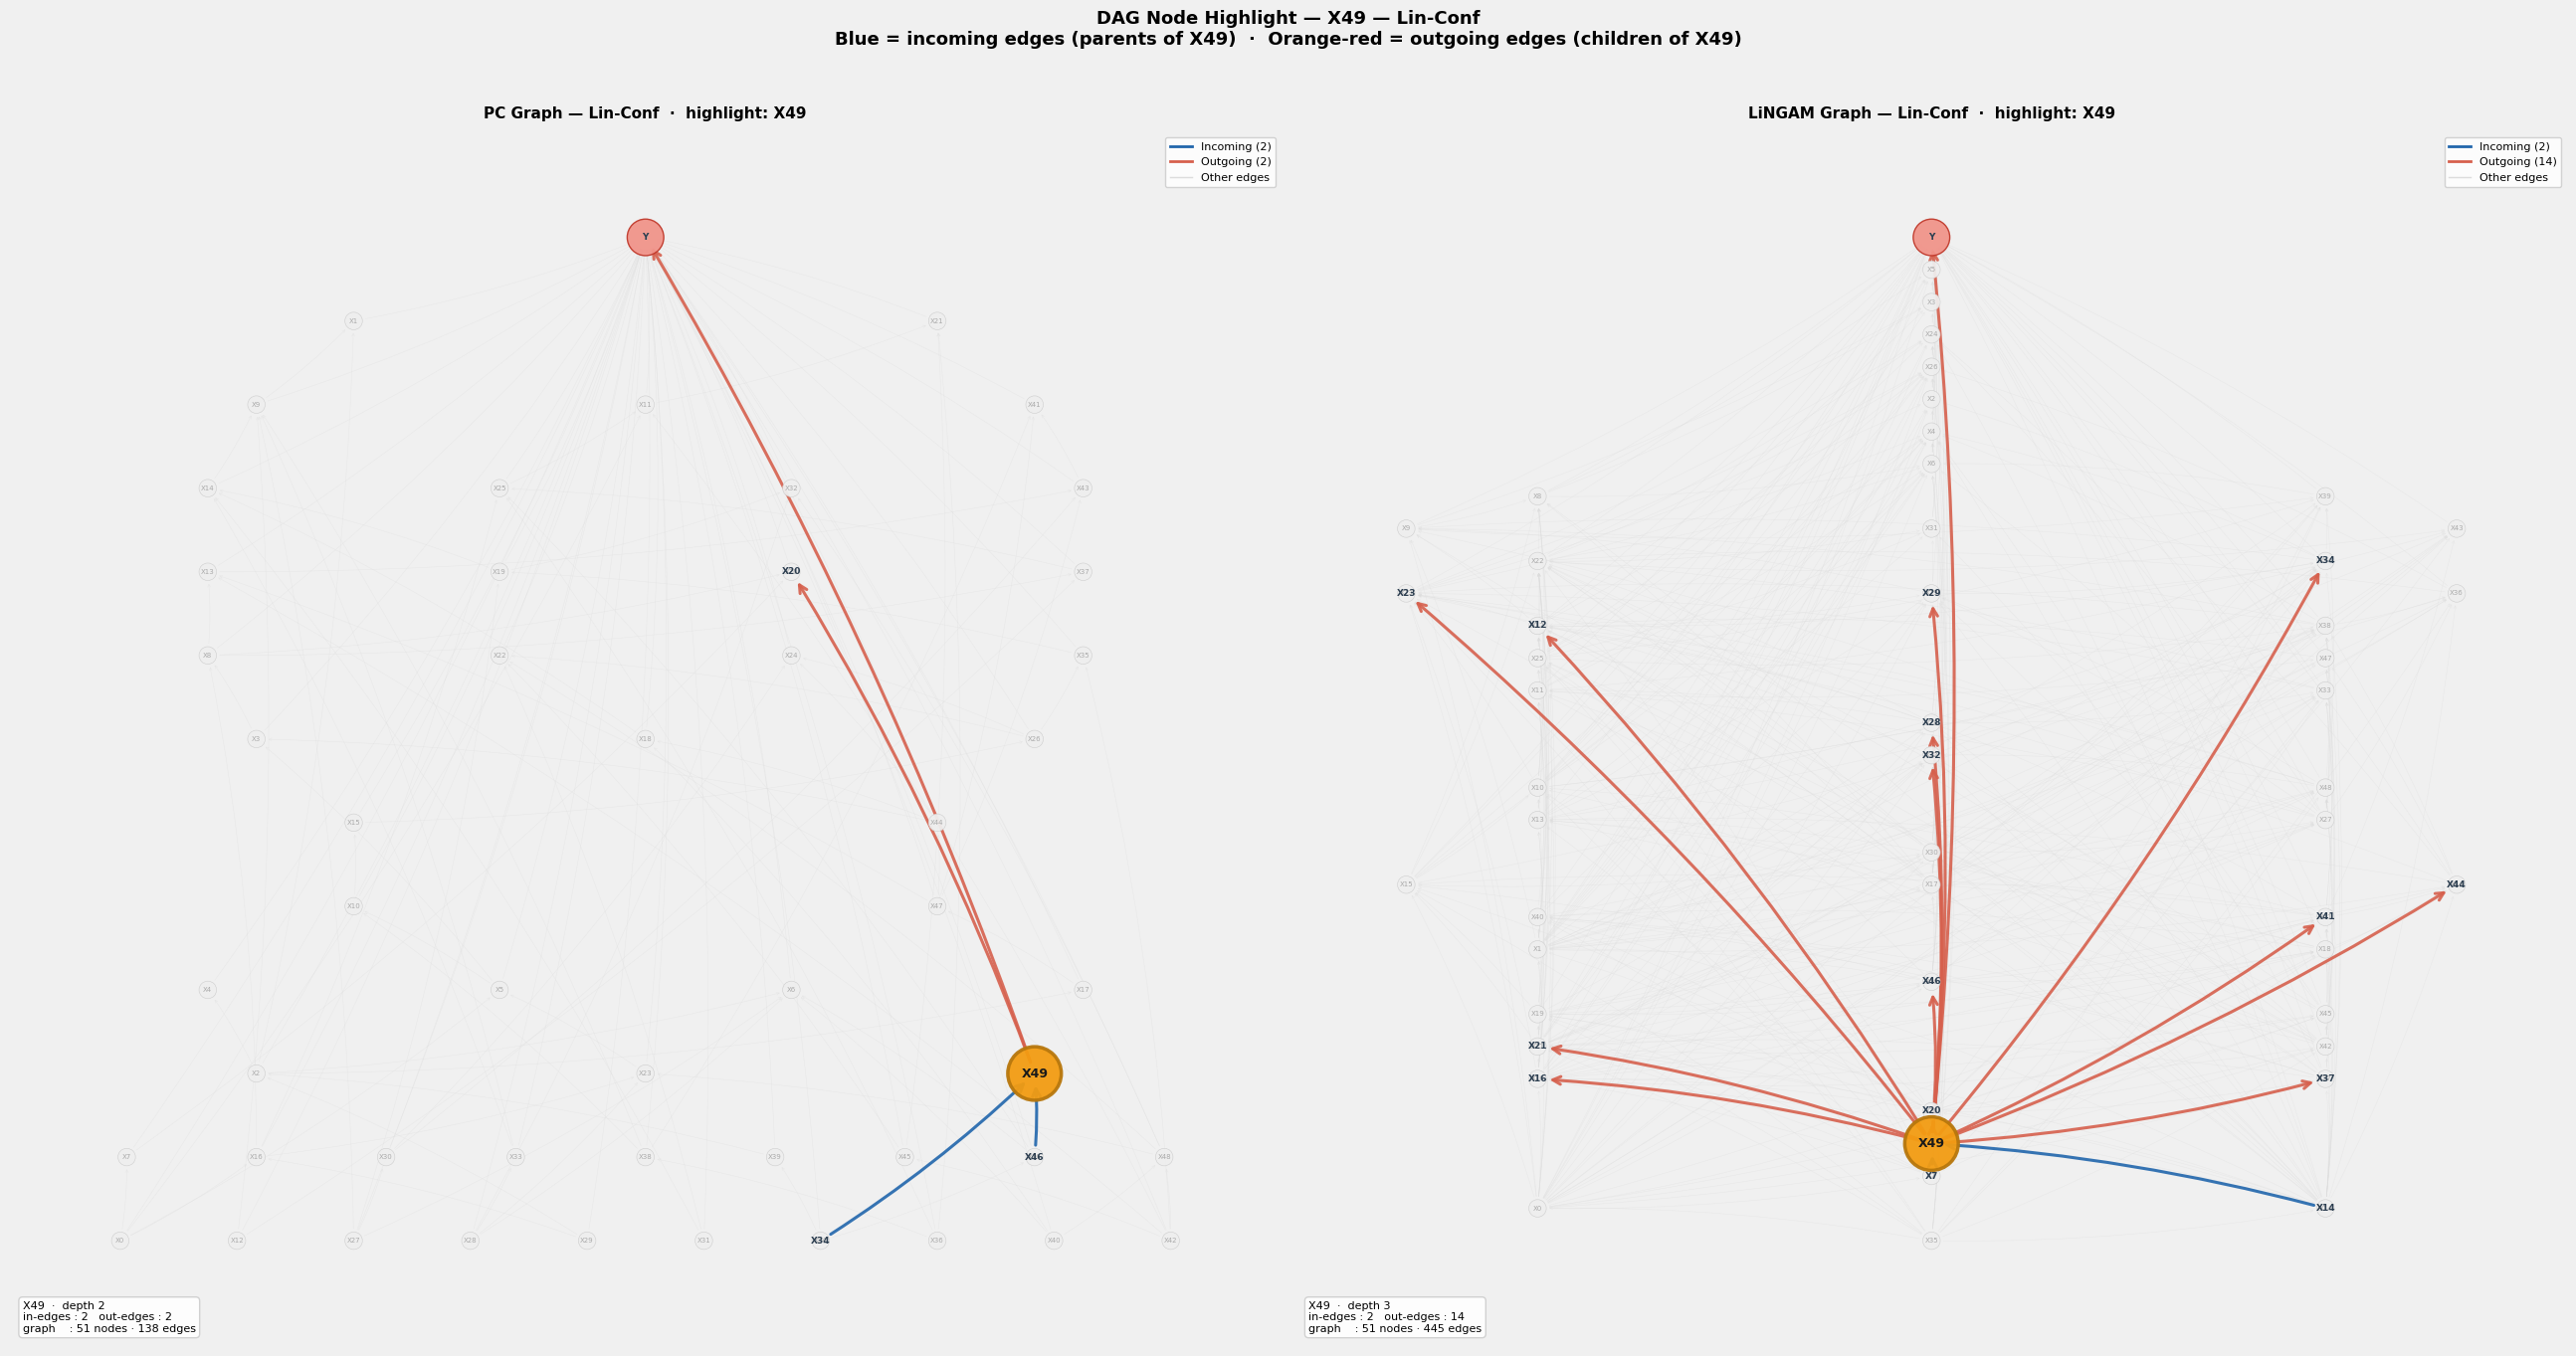

In [28]:
import matplotlib.pyplot as plt


def plot_dag_highlight(feature_name: str, dataset: str = None, figsize=(26, 14)):
    """
    Draw PC and LiNGAM DAGs side by side with one feature node highlighted,
    for a given dataset (or all datasets if dataset is None).

    Parameters
    ----------
    feature_name : str
        Name of the feature to highlight, e.g. "X5" or "X21".
    dataset : str or None
        One of the dataset keys in DATASETS, e.g. "linear_conf_f50_s1000_p50".
        If None, draws a figure for every dataset in DATASETS.
    figsize : tuple
        Figure size (width, height) per dataset panel.
    """
    targets = [dataset] if dataset is not None else DATASETS

    for ds in targets:
        c = dag_cache[ds]
        label = DS_LABELS[ds]

        fig, axes = plt.subplots(1, 2, figsize=figsize)
        fig.patch.set_facecolor("#f0f0f0")

        draw_dag_highlight(
            axes[0], c["G_pc"], c["pos_pc"], c["td_pc"], c["src_pc"],
            c["y_pc"], c["ml_pc"],
            title=f"PC Graph — {label}  ·  highlight: {feature_name}",
            highlight_name=feature_name,
            names=c["names"],
        )
        draw_dag_highlight(
            axes[1], c["G_lingam"], c["pos_lingam"], c["td_lingam"], c["src_lingam"],
            c["y_lingam"], c["ml_lingam"],
            title=f"LiNGAM Graph — {label}  ·  highlight: {feature_name}",
            highlight_name=feature_name,
            names=c["names"],
        )

        fig.suptitle(
            f"DAG Node Highlight — {feature_name} — {label}\n"
            f"Blue = incoming edges (parents of {feature_name})  ·  "
            f"Orange-red = outgoing edges (children of {feature_name})",
            fontsize=13, fontweight="bold", y=0.99,
        )
        plt.tight_layout(rect=[0, 0.02, 1, 0.97])
        plt.show()


# ── Example usage ─────────────────────────────────────────────────────────────
# Change the feature name to any node of interest identified from Section 8.
# Pass a specific dataset key to see only one graph, or omit for all datasets.
plot_dag_highlight("X49")